# 🌍 Analyse des Données de la Banque Mondiale (World Bank)

Ce notebook est dédié à l'**Exploration Exploratoire des Données (EDA)** et au **nettoyage** du jeu de données initial provenant de la Banque Mondiale.

### 📝 Objectifs du Notebook
1.  **Chargement des données** : Importation du fichier `world_bank_data.csv`.
2.  **Audit de qualité** : Identification des valeurs manquantes, des doublons et des types de données.
3.  **Analyse Statistique** : Calcul des indicateurs clés (PIB, Population, Taux de pauvreté).
4.  **Nettoyage** : Traitement des données aberrantes et préparation du fichier final pour la visualisation.

### 🛠️ Bibliothèques utilisées
*   `Pandas` : Manipulation des données.
*   `Matplotlib` & `Seaborn` : Visualisations préliminaires.

---
**Sortie :** Génère le fichier nettoyé `data_World_bank.csv`.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Création du dossier
folder_path = "../Data/Data_Cleanning"

os.makedirs(folder_path, exist_ok=True)

file_path = os.path.join(folder_path, "data_World_bank.csv")

In [3]:
# Déclaration des dataframes à partir du fichier csv :
data = pd.read_csv("..\Data\world_bank_data.csv")

============== EDA ==============

In [4]:
# Afficher le nombre de lignes et de colonnes
print("\n======= Shape of dataset: =======\n",data.shape)


======= Shape of dataset: =======
 (555, 8)


In [5]:
# Statistique descriptive:
print("\n======= Descriptive statistics (numeric): =======\n",data.describe())


======= Descriptive statistics (numeric): =======
               year           GDP  GDP Growth  Government Spending  \
count   555.000000  5.550000e+02  555.000000           531.000000   
mean   2017.000000  5.937075e+11    1.999828            19.445426   
std       4.324391  9.379394e+11    3.709531             3.841849   
min    2010.000000  4.010886e+09  -28.758584            11.065457   
25%    2013.000000  4.822987e+10    0.752307            17.562587   
50%    2017.000000  1.981607e+11    2.192938            19.255704   
75%    2021.000000  5.728049e+11    3.752951            21.438927   
max    2024.000000  4.685593e+12   24.623986            41.855693   

         Population     Poverty  Urban Population  
count  5.550000e+02  467.000000      5.550000e+02  
mean   1.983795e+07    0.973019      1.473865e+07  
std    2.982944e+07    1.767312      2.279371e+07  
min    3.180410e+05    0.000000      2.972370e+05  
25%    2.866970e+06    0.100000      1.649004e+06  
50%    8.37333

In [6]:
# Les 1ers lignes de data:
print("\n======= First rows of dataset: =======\n",data.head())


======= First rows of dataset: =======
    country  year           GDP  GDP Growth  Government Spending  Population  \
0  Albania  2010  1.208655e+10    2.973154            11.689427   2913021.0   
1  Albania  2011  1.297376e+10    2.463517            11.873033   2905195.0   
2  Albania  2012  1.224650e+10    0.984130            11.742913   2860708.0   
3  Albania  2013  1.279699e+10    1.707228            11.767684   2816902.0   
4  Albania  2014  1.329632e+10    2.240227            12.274638   2773767.0   

   Poverty  Urban Population  
0      NaN         1511321.0  
1      NaN         1548229.0  
2      1.8         1540885.0  
3      NaN         1529521.0  
4      3.7         1518154.0  


In [7]:
# Informations de data:
print("\n======= Dataset info: =======\n")
data.info()


======= Dataset info: =======

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              555 non-null    object 
 1   year                 555 non-null    int64  
 2   GDP                  555 non-null    float64
 3   GDP Growth           555 non-null    float64
 4   Government Spending  531 non-null    float64
 5   Population           555 non-null    float64
 6   Poverty              467 non-null    float64
 7   Urban Population     555 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 34.8+ KB


In [8]:
# Les valeurs null:
print("\n======= Missing values: =======\n",data.isnull().sum().sort_values(ascending=False))


======= Missing values: =======
 Poverty                88
Government Spending    24
country                 0
year                    0
GDP                     0
GDP Growth              0
Population              0
Urban Population        0
dtype: int64


In [9]:
# Les doublons:
print("\n======= Data duplicat: =======\n",data.duplicated().sum())


======= Data duplicat: =======
 0


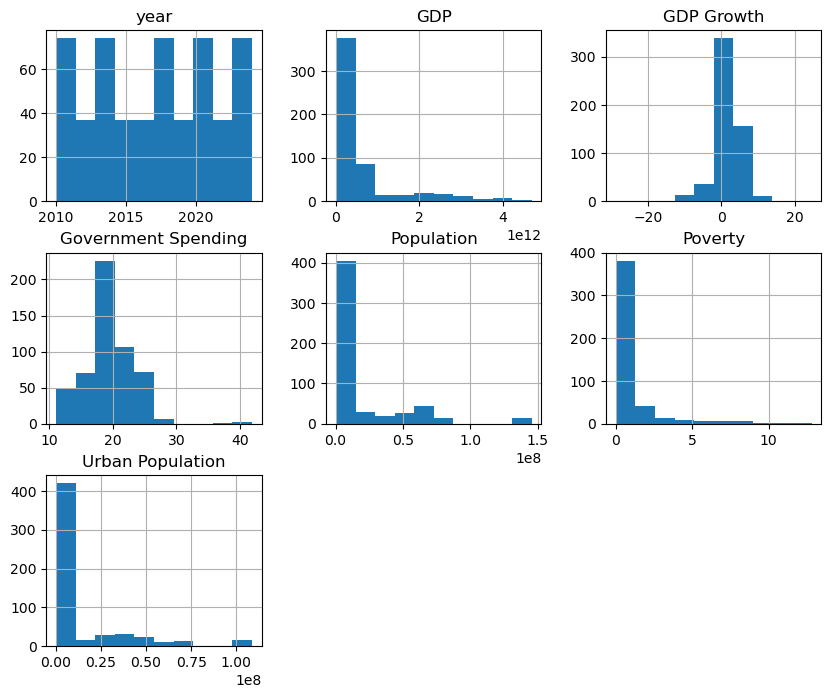

In [10]:
# Distribution Analysis
data.hist(figsize=(10,8))
plt.show()

============== Nettoyage ==============

In [11]:
# Conversion du type de la variable temporelle
data['year'] = pd.to_datetime(data['year'], format='%Y')

In [12]:
# Remplir les valeurs manquantes de "Poverty"
# On utilise la médiane par pays pour garder la cohérence économique de chaque pays
data["Poverty"] = data.groupby("country")["Poverty"].transform(lambda x: x.fillna(x.median()))

In [13]:
# Remplir les valeurs manquantes de "Government Spending"
# Ici on utilise la médiane globale car le nombre de valeurs manquantes est faible
data["Government Spending"] = data["Government Spending"].fillna(data["Government Spending"].median())

In [14]:
# Vérification après nettoyage les valeurs null:
print("\n======= Missing values after cleaning: =======\n",data.isnull().sum().sort_values(ascending=False))


======= Missing values after cleaning: =======
 country                0
year                   0
GDP                    0
GDP Growth             0
Government Spending    0
Population             0
Poverty                0
Urban Population       0
dtype: int64


In [15]:
# Sauvegarde des données nettoyées dans un fichier CSV
data.to_csv(file_path, index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
